# Model X — Full model (jockeying + abandonments) on $\widetilde{S}$
### $\gamma_1, \gamma_2, \theta_1, \theta_2$ all non-zero

The most general variant. Since no closed-form PGF exists for the full model,
analysis is entirely numerical via the $\widetilde{S}$-native CTMC solver.

We study how jockeying and abandonments interact, and show that all previous
models are special cases of this one.

In [1]:
%matplotlib inline
import sys, os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.gridspec import GridSpec

from model_master import Params, solve_exact, diagnostics
from model_master_tilde import (
    solve_exact_tilde, simulate_tilde,
    convert_S_to_Stilde,
    P_tilde, marginals_tilde, diagnostics_tilde,
    P_tilde_approx_modelA, y_star,
)

plt.rcParams.update({
    "font.family": "DejaVu Serif", "mathtext.fontset": "cm",
    "axes.titlesize": 11, "axes.labelsize": 10,
    "legend.fontsize": 9, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "figure.dpi": 110, "savefig.dpi": 140, "savefig.bbox": "tight",
})

# ── shared plotting helpers ───────────────────────────────────────────────────

def tilde_heatmap(ax, pi_tilde, title, nmax=12, log=False, vmin=None, vmax=None):
    grid = pi_tilde[:nmax+1, :nmax+1].copy()
    n2i, ni = np.indices(grid.shape)
    grid[n2i > ni] = np.nan
    if log:
        grid = np.where(grid > 0, grid, np.nan)
        vm  = vmin or 1e-6
        vM  = vmax or float(np.nanmax(grid))
        im  = ax.imshow(grid, origin="lower", cmap="viridis",
                        norm=LogNorm(vmin=vm, vmax=vM))
    else:
        im = ax.imshow(grid, origin="lower", cmap="viridis",
                       vmin=vmin or 0, vmax=vmax or float(np.nanmax(grid)))
    ax.set_xlabel(r"$n$"); ax.set_ylabel(r"$n_2$")
    ax.set_title(title)
    ax.plot([0, nmax], [0, nmax], "w--", lw=0.8, alpha=0.6)
    return im

def ppgf_panel(ax, pi_tilde, p, ns=(1,2,3,5,8), show_approx=False, label_suffix=""):
    y = np.linspace(0.0, 1.0, 201)
    cols = plt.cm.viridis(np.linspace(0.15, 0.9, len(ns)))
    for n, c in zip(ns, cols):
        ax.plot(y, P_tilde(y, n, pi_tilde), color=c, lw=2.0,
                label=rf"$n={n}${label_suffix}")
        if show_approx:
            ax.plot(y, P_tilde_approx_modelA(y, n, p), color=c,
                    lw=1.3, ls="--", alpha=0.7)
    ax.set_xlabel(r"$y$"); ax.set_ylabel(r"$\widetilde{P}(y,n)$")
    ax.grid(alpha=0.3); ax.legend(fontsize=8)

def marginals_panel(ax, pi_tilde, kmax=14):
    m = marginals_tilde(pi_tilde)
    k = np.arange(min(kmax+1, len(m["pi_n1"])))
    ax.bar(k - 0.2, m["pi_n1"][:len(k)], 0.4, label=r"$\pi(n_1)$",
           color="#1f3a93", alpha=0.85)
    ax.bar(k + 0.2, m["pi_n2"][:len(k)], 0.4, label=r"$\pi(n_2)$",
           color="#c0392b", alpha=0.85)
    ax.set_xlabel("queue count"); ax.set_ylabel("probability")
    ax.legend(); ax.grid(alpha=0.3)

def metrics_row(name, p, r):
    d = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    print(f"  {name:<28} pi_0={r['pi_idle']:.4f}  P(busy)={d['P_busy']:.4f}"
          f"  E[N1]={d['E_n1']:.3f}  E[N2]={d['E_n2']:.3f}"
          f"  E[N]={d['E_n']:.3f}  throughput={d['throughput']:.4f}")

In [2]:
base = dict(lam1=0.3, lam2=0.4, mu=1.0)
scenarios = {
    "Model A":              Params(**base),
    "Model B (jockey)":     Params(**base, gamma1=0.5, gamma2=0.3),
    r"Model C2 (theta1)":   Params(**base, theta1=0.4),
    "Full (gamma+theta)":   Params(**base, gamma1=0.4, gamma2=0.2, theta1=0.2, theta2=0.1),
}
results = {}
for name, p in scenarios.items():
    r = solve_exact_tilde(p, n_max=60)
    results[name] = (p, r)
    metrics_row(name, p, r)

  Model A                      pi_0=0.3000  P(busy)=0.7000  E[N1]=0.300  E[N2]=1.333  E[N]=1.633  throughput=0.7000
  Model B (jockey)             pi_0=0.3000  P(busy)=0.7000  E[N1]=0.515  E[N2]=1.118  E[N]=1.633  throughput=0.7000
  Model C2 (theta1)            pi_0=0.3616  P(busy)=0.6384  E[N1]=0.154  E[N2]=0.745  E[N]=0.899  throughput=0.6384
  Full (gamma+theta)           pi_0=0.3862  P(busy)=0.6138  E[N1]=0.200  E[N2]=0.463  E[N]=0.663  throughput=0.6138


## 1. Cross-model joint distribution comparison

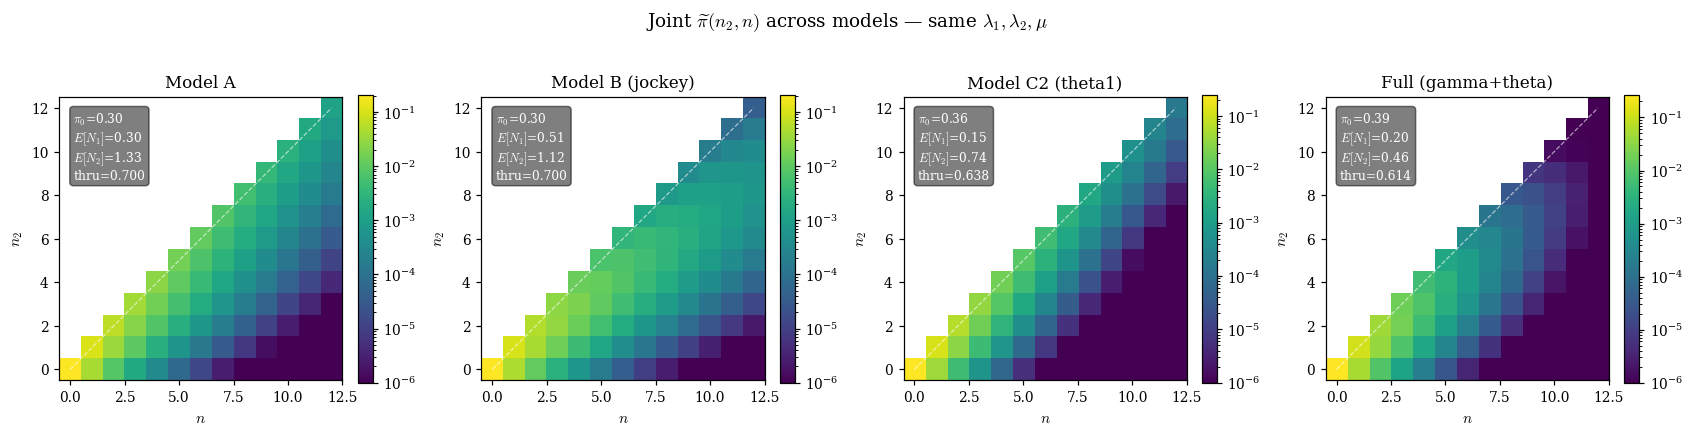

In [3]:
fig, axes = plt.subplots(1, 4, figsize=(15.5, 4.0))
for ax, (name, (p, r)) in zip(axes, results.items()):
    im = tilde_heatmap(ax, r["pi_tilde"], name, log=True, vmin=1e-6)
    d  = diagnostics_tilde(p, r["pi_idle"], r["pi_tilde"])
    ax.text(0.05, 0.95,
            f"$\\pi_0$={r['pi_idle']:.2f}\n"
            f"$E[N_1]$={d['E_n1']:.2f}\n$E[N_2]$={d['E_n2']:.2f}\n"
            f"thru={d['throughput']:.3f}",
            transform=ax.transAxes, va="top", ha="left", color="white",
            fontsize=8, bbox=dict(boxstyle="round", fc="black", alpha=0.5))
    plt.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(r"Joint $\widetilde{\pi}(n_2, n)$ across models — same $\lambda_1,\lambda_2,\mu$")
fig.tight_layout()

## 2. Combined effect: 2D sweep over $(\gamma_1, \theta_1)$

With $\gamma_2=\theta_2=0$ fixed, we vary both jockeying and abandonment rates
simultaneously. The contours show iso-performance curves for $E[N_1]$ and $E[N_2]$.

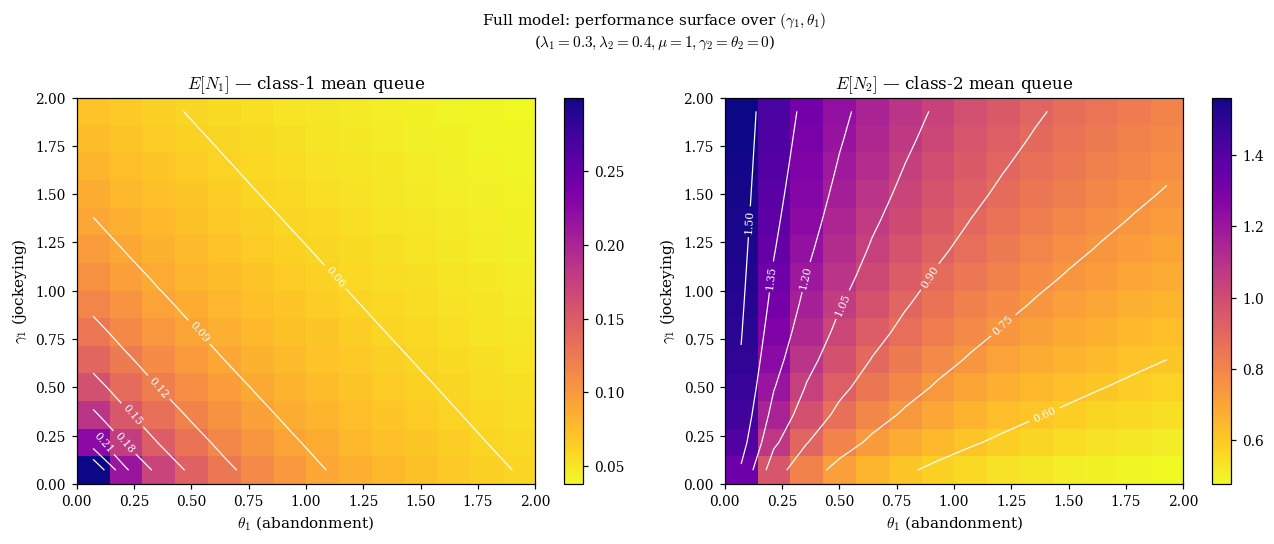

In [4]:
g1_vals = np.linspace(0.0, 2.0, 14)
t1_vals = np.linspace(0.0, 2.0, 14)
lam1, lam2, mu_b = 0.3, 0.4, 1.0

En1_surf = np.zeros((len(g1_vals), len(t1_vals)))
En2_surf = np.zeros_like(En1_surf)

for i, g1 in enumerate(g1_vals):
    for j, t1 in enumerate(t1_vals):
        pm = Params(lam1, lam2, mu_b, gamma1=g1, theta1=t1)
        r  = solve_exact_tilde(pm, n_max=50)
        d  = diagnostics_tilde(pm, r["pi_idle"], r["pi_tilde"])
        En1_surf[i, j] = d["E_n1"]
        En2_surf[i, j] = d["E_n2"]

fig, axes = plt.subplots(1, 2, figsize=(12, 5.0))
ext = [t1_vals[0], t1_vals[-1], g1_vals[0], g1_vals[-1]]
for ax, surf, title in [
    (axes[0], En1_surf, r"$E[N_1]$ — class-1 mean queue"),
    (axes[1], En2_surf, r"$E[N_2]$ — class-2 mean queue"),
]:
    im = ax.imshow(surf, origin="lower", extent=ext, aspect="auto", cmap="plasma_r")
    cs = ax.contour(surf, levels=8, colors="white", linewidths=0.8,
                    extent=ext, origin="lower")
    ax.clabel(cs, fmt="%.2f", fontsize=7)
    plt.colorbar(im, ax=ax)
    ax.set_xlabel(r"$\theta_1$ (abandonment)"); ax.set_ylabel(r"$\gamma_1$ (jockeying)")
    ax.set_title(title)
fig.suptitle(r"Full model: performance surface over $(\gamma_1, \theta_1)$"
             "\n" r"($\lambda_1=0.3, \lambda_2=0.4, \mu=1, \gamma_2=\theta_2=0$)",
             fontsize=10)
fig.tight_layout()

## 3. PPGF comparison across all four models

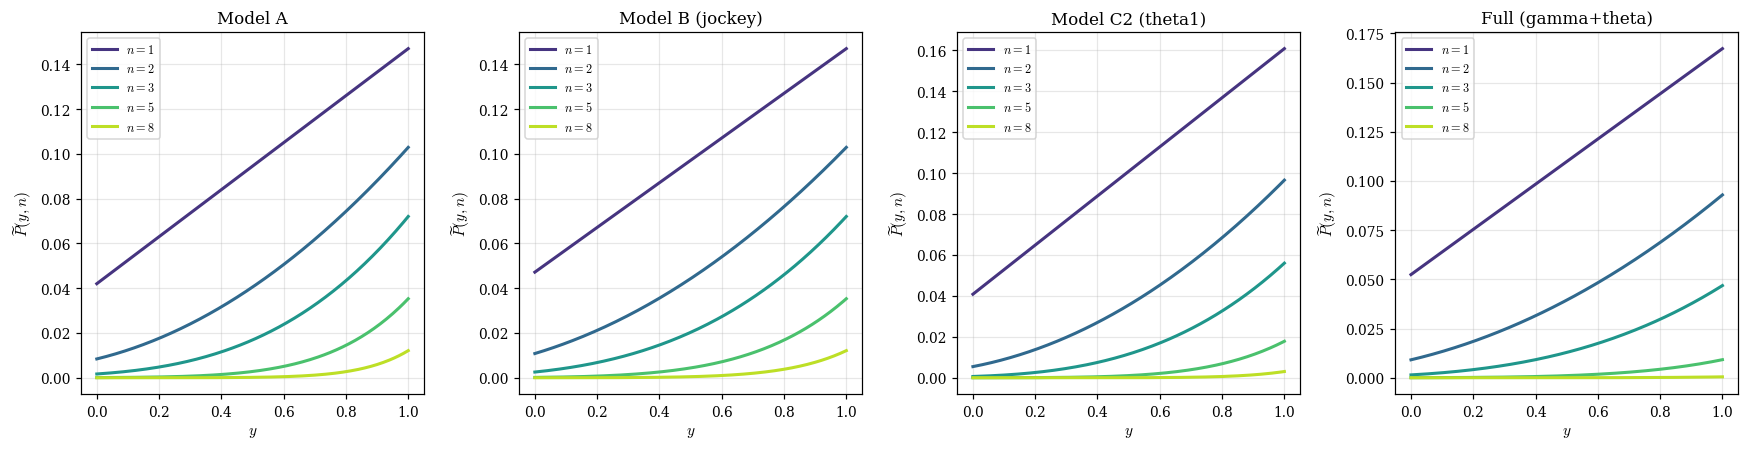

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4.2))
for ax, (name, (p, r)) in zip(axes, results.items()):
    ppgf_panel(ax, r["pi_tilde"], p)
    ax.set_title(name)
fig.tight_layout()

## 4. Special case verification: full model reduces to each sub-model

Set each combination of extra parameters to zero and check that the result
numerically matches the dedicated per-model solution.

In [6]:
lam1, lam2, mu_v = 0.3, 0.4, 1.0
g1, g2, t1, t2   = 0.5, 0.3, 0.4, 0.2

tests = [
    ("Model A (gamma=theta=0)",     Params(lam1, lam2, mu_v),
                                    Params(lam1, lam2, mu_v, gamma1=0, gamma2=0,
                                           theta1=0, theta2=0)),
    ("Model B (theta=0)",           Params(lam1, lam2, mu_v, gamma1=g1, gamma2=g2),
                                    Params(lam1, lam2, mu_v, gamma1=g1, gamma2=g2,
                                           theta1=0, theta2=0)),
    ("Model C2 (gamma=theta2=0)",   Params(lam1, lam2, mu_v, theta1=t1),
                                    Params(lam1, lam2, mu_v, gamma1=0, gamma2=0,
                                           theta1=t1, theta2=0)),
]
print(f"{'test':<35} {'max|pi_special - pi_full|':>28}")
print("─" * 65)
for name, p_special, p_full in tests:
    r_sp = solve_exact_tilde(p_special, n_max=50)
    r_fu = solve_exact_tilde(p_full,    n_max=50)
    sh   = min(r_sp["pi_tilde"].shape[0], r_fu["pi_tilde"].shape[0])
    diff = np.max(np.abs(r_sp["pi_tilde"][:sh,:sh] - r_fu["pi_tilde"][:sh,:sh]))
    print(f"{name:<35} {diff:>28.2e}")

test                                   max|pi_special - pi_full|
─────────────────────────────────────────────────────────────────
Model A (gamma=theta=0)                                 0.00e+00
Model B (theta=0)                                       0.00e+00
Model C2 (gamma=theta2=0)                               0.00e+00
